In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("/Users/tshmacm1171/Downloads/house_data_200.csv")

In [3]:
df.head(4)

,Size_sqft,Bedrooms,Bathrooms,Floors,Age,Location_Score,Garage,Price
0,1926,4,1,2,18,8,0,2593945
1,2259,5,3,2,20,5,0,2742224
2,1660,2,3,2,8,7,0,2280738
3,2094,4,2,1,9,7,1,2799150


In [19]:
X_f = df.drop('Price', axis=1)
y=df["Price"]

In [5]:
# Numeric columns: everything except categorical
num_value = [col for col in X_f.columns if col not in ['Garage']]  

# Categorical columns
cat_value = ['Garage']  

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(drop='first', sparse_output=False)


preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_value),
        ('cat', categorical_transformer , cat_value)
    ],
    remainder='passthrough'  # keeps other columns
)

In [7]:
X_processed = preprocessor.fit_transform(X_f)

In [10]:
#convert the array back to pd

import pandas as pd

X_processed_df = pd.DataFrame(
    X_processed,
    columns=preprocessor.get_feature_names_out()
)

In [12]:
X_processed_df.head(5)

,num__Size_sqft,num__Bedrooms,num__Bathrooms,num__Floors,num__Age,num__Location_Score,cat__Garage_1
0,0.529349,0.323994,-1.208941,1.128152,0.762027,0.260909,0.0
1,1.228970,1.176611,1.336198,1.128152,1.041927,-1.440673,0.0
2,-0.029508,-1.381239,1.336198,1.128152,-0.637472,-0.306285,0.0
3,0.882311,0.323994,0.063628,-0.886405,-0.497522,-0.306285,1.0
4,0.537753,-0.528622,1.336198,1.128152,-0.777421,-0.306285,1.0


In [13]:
X=X_processed_df

In [23]:
# ready to train the model
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test= train_test_split(X,y, test_size=0.2, random_state=42)

estimator=KNeighborsRegressor(n_neighbors=5)
estimator.fit(X_train,y_train)



,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [24]:
y_predicted=estimator.predict(X_test)

In [25]:
# testing the metrics of our model

from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

mse=mean_squared_error(y_test, y_predicted)
r2=r2_score(y_test, y_predicted)
rmse=np.sqrt(mse)

print("Mean Square Error is :", mse)
print("R squared is :", r2)
print("Root Mean Square Error is: ", rmse)

Mean Square Error is : 41131442366.27601
R squared is : 0.816644312331736
Root Mean Square Error is:  202808.8813791842


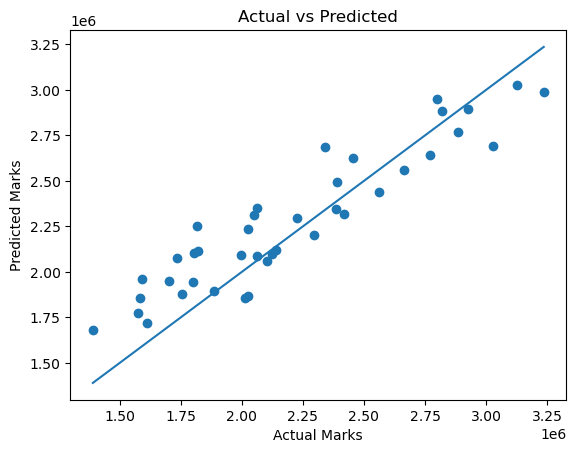

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# Convert to arrays (prevents most errors)
y_test_array = np.array(y_test)
y_pred_array = np.array(y_predicted)

plt.scatter(y_test_array, y_pred_array)

# Perfect line
min_val = min(y_test_array.min(), y_pred_array.min())
max_val = max(y_test_array.max(), y_pred_array.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual vs Predicted")

plt.show()